# Semantic segmentation project

## Importing Libraries

In [1]:
import tensorflow as tf
import numpy as np
import glob
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
from sklearn.utils import shuffle

2026-03-21 00:04:43.192817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774047883.528272     571 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774047883.671591     571 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774047884.755016     571 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774047884.755066     571 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774047884.755071     571 computation_placer.cc:177] computation placer alr

## Loading Data

In [2]:
parent = "./data"

train_images_dir = "/training/image_2/*.png"
train_masks_dir = "/training/gt_image_2/*road*.png"

test_images_dir = "/testing/image_2/*.png"
#test_masks_dir = "./testing/gt_image_2/*"

In [3]:
def get_images_list(path):
    images_list = glob.glob(parent+path)
    return images_list

In [4]:
def load_data(train=0):
    if train:
        images_list = get_images_list(train_images_dir)
        masks_list = get_images_list(train_masks_dir)
        return images_list, masks_list
    else:
        images_list = get_images_list(test_images_dir)
        #masks_list = get_images_list(test_masks_dir)
        return images_list

def load_images(path_list):
    images = []
    for path in path_list:
        image = cv2.resize(cv2.imread(path), (224, 224))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
    return np.stack(images, dtype=np.uint8)

In [5]:
train_images_path_list, train_masks_path_list = load_data(train=1)
train_images_path_list, train_masks_path_list = shuffle(train_images_path_list, train_masks_path_list, random_state=42)
test_images_path_list = load_data()

In [6]:
print("Total train images = " + str(len(train_images_path_list)))
print("Total train masks = " + str(len(train_masks_path_list)))
print("Total test images = " + str(len(test_images_path_list)))

Total train images = 289
Total train masks = 289
Total test images = 290


In [7]:
unp_train_images = load_images(train_images_path_list)
unp_test_images = load_images(test_images_path_list)
unp_train_masks = load_images(train_masks_path_list)

In [8]:
#unp_train_images, unp_train_masks = shuffle(unp_train_images, unp_train_masks, random_state=42)

## Data preprocessing

In [9]:
def preprocess_image(images):
    im_list = []
    images = images.astype(np.float32)
    new_im = (images-128)/128
    return np.stack(new_im)

def preprocess_masks(masks):
    mask_list = []
    for mask in masks:
        mask_list.append(mask/255)
    return np.array(mask_list, dtype=np.uint8)

In [10]:
## Preprocess Pipeline
# 1. Load images
# 2. Normalize the data
train_images = preprocess_image(unp_train_images)

train_masks = preprocess_masks(unp_train_masks)#/255, dtype=np.uint8)


test_images = preprocess_image(unp_test_images)

In [11]:
print(f"Shape of train images {train_images.shape}")
print(f"Shape of train masks {train_masks.shape}")
print(f"Shape of test images {test_images.shape}")

Shape of train images (289, 224, 224, 3)
Shape of train masks (289, 224, 224, 3)
Shape of test images (290, 224, 224, 3)


## Model definition

In [31]:
from tensorflow.keras.applications import ResNet50, VGG16
from keras.layers import UpSampling2D, Conv2D, Concatenate, Conv2DTranspose, BatchNormalization, Activation, MaxPooling2D
from keras.models import Model
from tensorflow.keras.callbacks import *

In [32]:
pre_mod = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
for layer in pre_mod.layers:
    print(layer.name)

input_layer_3
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [33]:
def pretrained_cnn_model(input_shape, trainable=False):
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    backbone.trainable=trainable
    return backbone

def pretrained_vgg16(input_shape, trainable=False):
    backbone = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    backbone.trainable=trainable
    return backbone

In [34]:
def conv_block(x, depth, encoder=0):
    x = Conv2D(depth, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(depth, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    if encoder:
        x = MaxPooling2D()(x)
    return x 

In [130]:
def encoder(input_shape, base_model):
    layer_names = [
        "conv1_relu",
        "conv2_block3_out",
        "conv3_block4_out",
        "conv4_block6_out",
        "conv5_block3_out"
    ]
    layers = [base_model.get_layer(name).output for name in layer_names]
    model = Model(base_model.input, layers)
    return model

def encoder_fcn(input_shape, base_model):
    layer_names = [
        "block3_pool",
        "block4_pool",
        "block5_pool"
    ]
    layers = [base_model.get_layer(name).output for name in layer_names]
    model = Model(base_model.input, layers)
    return model

def additional_encoder(x, num_classes, encode):
    x = Conv2D(4096, 7, padding="same", activation="relu")(x)
    x = Conv2D(4096, 1, padding="same", activation="relu")(x)
    x = Conv2D(num_classes, 1, padding="same", activation="relu")(x)
    #print(x.shape)
    return x

In [131]:
def transpose_block(x, filters, conc=[], skip=1):
    x = UpSampling2D()(x)
    if skip:
        x = Concatenate()([x, conc])
    output = conv_block(x, filters)
    return output

In [132]:
def decoder(inp, skip):
    #print(inp.shape)
    x = transpose_block(inp, 512, skip[-1])
    x = transpose_block(x, 256, skip[2])
    x = transpose_block(x, 128, skip[1])
    output = transpose_block(x, 64, skip[0])
    return output

def decoder_fcn(inp, skip, num_classes):
    print(inp.shape)
    x = transpose_block(inp, num_classes, skip[-1])
    print(x.shape)
    print(skip[0].shape)
    x = transpose_block(x, num_classes, skip[0])
    output = transpose_block(x, 64, skip=0)
    return output

In [133]:
def seg_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_cnn_model(input_shape, trainable=False)
    encoder_out = encoder(input_shape, base_model)
    c1, c2, c3, c4, c5 = encoder_out.output
    decoder_out = decoder(c5, [c1, c2, c3, c4])
    x = Conv2DTranspose(32, 2, 2, padding="same")(decoder_out)
    output = Conv2D(num_classes, 1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

def fcn8_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_vgg16(input_shape, trainable=False)
    encoder_out = encoder_fcn(input_shape, base_model)
    num_classes=3
    c1, c2, c3 = encoder_out.output
    c3 = additional_encoder(c3, num_classes, 1)
    decoder_out = decoder_fcn(c3, [c1, c2], num_classes)
    output = Conv2DTranspose(num_classes, 8, 2, padding="same")(decoder_out)
    #output = Conv2D(num_classes, 1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

## Model training

In [134]:
batch_size=4
learning_rate=1e-4
epochs = 10#60

In [135]:
model = fcn8_model()
#model = seg_model()
#model = Model(backbone.input, output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

2026-03-21 01:06:10.811195: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 392.00MiB (rounded to 411041792)requested by op AddV2
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-03-21 01:06:10.811855: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2026-03-21 01:06:10.812091: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 109, Chunks in use: 109. 27.2KiB allocated for chunks. 27.2KiB in use in bin. 8.6KiB client-requested in use in bin.
2026-03-21 01:06:10.812111: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (512): 	Total Chunks: 35, Chunks in use: 35. 20.0KiB allocated for chunks. 20.0KiB in use in bin. 16.9KiB client-requested in use in bin.
2026-

ResourceExhaustedError: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:AddV2] name: 

ext 627
2026-03-21 01:06:10.816651: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a40b00 of size 2048 next 587
2026-03-21 01:06:10.816657: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a41300 of size 2048 next 617
2026-03-21 01:06:10.816664: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a41b00 of size 3328 next 572
2026-03-21 01:06:10.816670: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a42800 of size 6912 next 593
2026-03-21 01:06:10.816676: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a44300 of size 285952 next 602
2026-03-21 01:06:10.816682: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681a8a000 of size 442368 next 459
2026-03-21 01:06:10.816689: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1114] InUse at 681af6000 of size 2048 next 585
2026-03-21 01:06:10.816700: I external/local_xla/xla/tsl/framework/bfc_

In [113]:
callbacks = [
    ReduceLROnPlateau(
        monitor='loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    ),

    EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_model.keras",
        save_best_only=True
    )
]

In [43]:
model.fit(
    train_images,
    train_masks,
    batch_size=batch_size,
    epochs=epochs,
    #callbacks=callbacks
)

NameError: name 'model' is not defined

In [23]:
model.save("model_fcn8.keras")

NameError: name 'model' is not defined

## Finetuning model

In [25]:
results = model.predict(test_images)

2026-03-20 23:40:24.341380: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.66 = (f32[32,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0} %bitcast.1188, f32[64,3,3,3]{3,2,1,0} %bitcast.1195, f32[64]{0} %bitcast.1197), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/block1_conv1_1/convolution" source_file="/home/forby/miniconda3/envs/sdc/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-03-20 23:40:24.502431: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.

 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step

2026-03-20 23:40:52.067668: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.73 = (f32[2,512,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[2,256,28,28]{3,2,1,0} %bitcast.1290, f32[512,256,3,3]{3,2,1,0} %bitcast.1297, f32[512]{0} %bitcast.1299), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1_1/block4_conv1_1/convolution" source_file="/home/forby/miniconda3/envs/sdc/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-03-20 23:40:52.333955: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker

10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step


In [26]:
p = 20

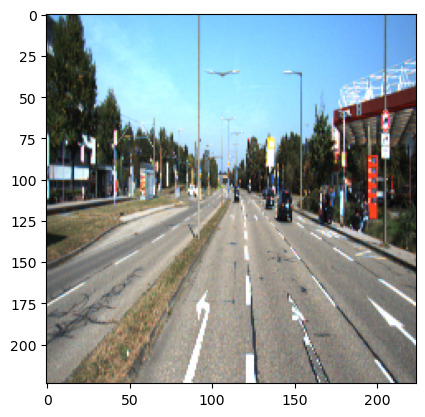

In [27]:
plt.imshow(unp_test_images[p])

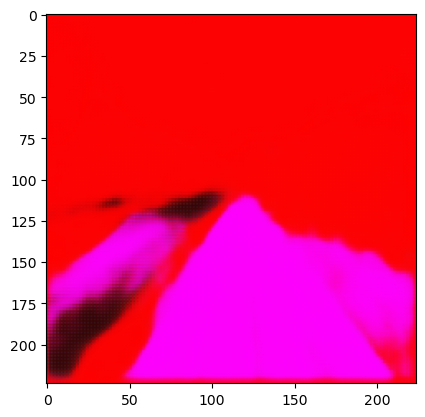

In [28]:
plt.imshow(results[p])

In [29]:
def save_image(image, mask, alpha=0.3):
    if hasattr(mask, "numpy"):
        mask = mask.numpy()
    if hasattr(image, "numpy"):
        image = image.numpy()
    masked_mask = (mask >= 0.9).astype(np.uint8)
    mask_only = (masked_mask[..., 0] == 1) & (masked_mask[..., 2] == 1)
    mask_only = mask_only.astype(np.uint8) * 255
    mask_rgb = np.zeros_like(image)
    mask_rgb[mask_only == 255] = [0, 255, 0]
    overlay = cv2.addWeighted(image, 1 - alpha, mask_rgb, alpha, 0)

    return overlay

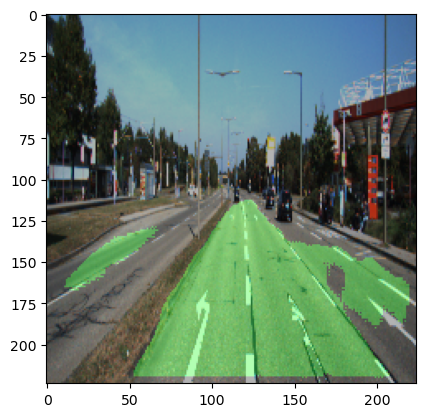

In [30]:
for i, (image, mask) in enumerate(zip(unp_test_images, results)):
    n_im = save_image(image, mask)
    if i == p:
        plt.imshow(n_im)
    cv2.imwrite(f"./data/processed_data/im{i}.png", n_im)

In [31]:
def seg_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_cnn_model(input_shape, trainable=True)
    encoder_out = encoder(input_shape, base_model)
    c1, c2, c3, c4, c5 = encoder_out.output
    decoder_out = decoder(c5, [c1, c2, c3, c4])
    x = Conv2DTranspose(32, 2, 2, padding="same")(decoder_out)
    output = Conv2D(num_classes, 1, activation="softmax")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

def fcn8_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = pretrained_vgg16(input_shape, trainable=True)
    encoder_out = encoder_fcn(input_shape, base_model)
    c1, c2, c3 = encoder_out.output
    c3 = 
    decoder_out = decoder_fcn(c3, [c1, c2])
    x = Conv2DTranspose(32, 2, 2, padding="same")(decoder_out)
    output = Conv2D(num_classes, 1, activation="sigmoid")(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

In [32]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

In [33]:
model.fit(
    train_images,
    train_masks,
    batch_size=batch_size,
    epochs=10,
)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.9562 - loss: 0.0193
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.9639 - loss: 0.0176
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9692 - loss: 0.0166
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - accuracy: 0.9729 - loss: 0.0156
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 98ms/step - accuracy: 0.9753 - loss: 0.0148
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9780 - loss: 0.0141
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9807 - loss: 0.0134
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.9817 - loss: 0.0128
Epoch 9/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9833 - loss: 0.0123
Epoch 10/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.9851 - loss: 0.0117


## Evaluation and Metrics

## Performing inference

In [34]:
def pipeline(image):
    original = image.shape
    image = preprocess_image(cv2.resize(image, (224, 224)))
    image = image.reshape([-1, image.shape[0], image.shape[1], image.shape[2]])
    pred = model.predict(image)
    n_im = cv2.resize(save_image(image[0], pred[0]), (original[1], original[0]))
    return n_im

In [35]:
import moviepy
from moviepy import VideoFileClip, ImageSequenceClip
import numpy as np
from tqdm import tqdm

class images_to_video():
    def __init__(self, images, video_path, fps):
        self.image_list = images
        self.video_path = video_path
        self.fps = fps


    def __call__(self):
        if self.image_list.dtype != np.uint8:
            if self.image_list.max() <= 1.0:
                self.image_list = (self.image_list * 255).astype(np.uint8)
            else:
                self.image_list = self.image_list.astype(np.uint8)
        clip = ImageSequenceClip(list(self.image_list), fps=self.fps)
        clip.write_videofile(self.video_path, codec="libx264", audio=False)
        print("Writing Video Completed")



class video_to_images():
    def __init__(self, video_path, fps=None):
        self.video_path = video_path
        self.fps = fps


    def __call__(self):
        clip = VideoFileClip(self.video_path)
        if self.fps:
            clip = clip.with_fps(self.fps)
        frames = clip.iter_frames()
        frames_list = list(frames)
        return np.array(frames_list)

In [36]:
fps=7
images = video_to_images("./driving.mp4", fps)()
#image = Image.open('./assets/sample1.jpg')
#images = np.expand_dims(np.asarray(image, dtype=np.uint8), 0)
print(images.shape)
processed_images = []
for image in images:
    processed_images.append(pipeline(image))
#    break
#plt.imshow(processed_images[0])

(352, 720, 1280, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━

In [22]:
save=images_to_video(np.array(processed_images), "./result.mp4", fps)()

NameError: name 'images_to_video' is not defined